# Emulsion Steady Shear (Herschel-Bulkley)

Fit multiple emulsion volume fractions with Herschel–Bulkley to mirror pyRheo rotation demos.

**Data:** examples/data/flow/emulsions/*.csv


In [1]:
# Google Colab compatibility - uncomment if running in Colab
# !pip install -q rheojax
# from google.colab import drive
# drive.mount('/content/drive')


## Setup and Imports

In [2]:
# Configure matplotlib for inline plotting in VS Code/Jupyter
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from rheojax.core.data import RheoData
from rheojax.core.jax_config import safe_import_jax, verify_float64
from rheojax.models import FractionalMaxwellModel, GeneralizedMaxwell, HerschelBulkley
from rheojax.pipeline.base import Pipeline
from rheojax.transforms.mastercurve import Mastercurve

jax, jnp = safe_import_jax()
verify_float64()
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
warnings.filterwarnings('ignore', category=RuntimeWarning)

def r2_complex(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    ss_res = np.sum(np.abs(y_true - y_pred) ** 2)
    ss_tot = np.sum(np.abs(y_true - np.mean(y_true)) ** 2)
    return float(1 - ss_res / ss_tot)

def mpe(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred) / np.maximum(np.abs(y_true), 1e-12)) * 100)
import os
import sys

import arviz as az

# Shared plotting utilities
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("")), ".."))
from utils.plotting_utils import display_arviz_diagnostics
from IPython.display import display


## Load steady-shear data

In [3]:
DATA_DIR = Path.cwd().parent / 'data' / 'flow' / 'emulsions'
files = sorted(DATA_DIR.glob('*.csv'))
frames = []
for f in files:
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()
    df = df.dropna()
    df['phi'] = f.stem
    frames.append(df)
all_df = pd.concat(frames, ignore_index=True)
print(all_df.head())


   Shear Rate    Stress   phi  0.001003995054076478  4.6626050233384495  \
0    0.001570  4.717239  0.69                   NaN                 NaN   
1    0.002472  4.704130  0.69                   NaN                 NaN   
2    0.004041  4.743921  0.69                   NaN                 NaN   
3    0.006120  4.774533  0.69                   NaN                 NaN   
4    0.010096  4.855836  0.69                   NaN                 NaN   

   0.0009962854762886107  7.445899342994139  0.0010021527764970915  \
0                    NaN                NaN                    NaN   
1                    NaN                NaN                    NaN   
2                    NaN                NaN                    NaN   
3                    NaN                NaN                    NaN   
4                    NaN                NaN                    NaN   

   9.948157317915243  0.0010147845822195973  13.147187538756189  \
0                NaN                    NaN                 N

## Fit Herschel-Bulkley per volume fraction

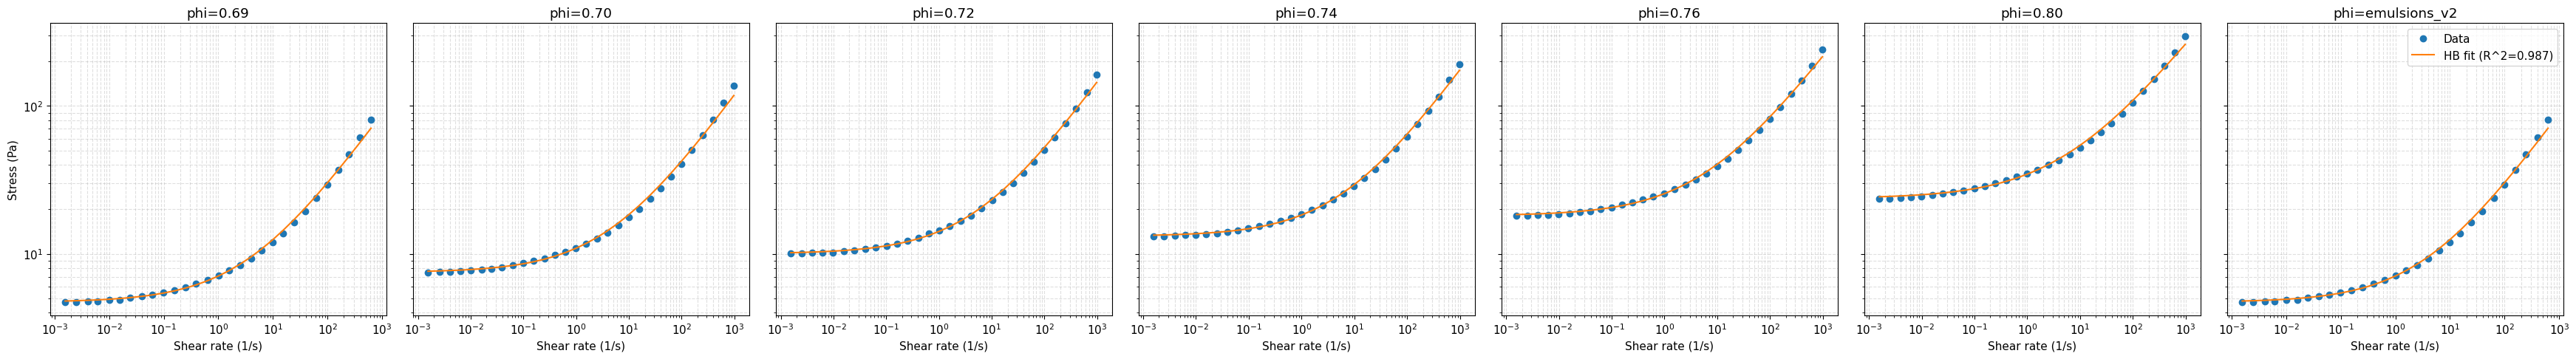

In [4]:
fig, axes = plt.subplots(1, len(files), figsize=(5*len(files),5), sharey=True)
for ax, f in zip(axes, files):
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()
    df = df.dropna()
    gamma_dot = df.iloc[:,0].to_numpy()
    tau = df.iloc[:,1].to_numpy()

    model = HerschelBulkley()
    model.fit(gamma_dot, tau, test_mode='rotation')
    tau_pred = model.predict(gamma_dot)
    r2 = model.score(gamma_dot, tau)

    ax.loglog(gamma_dot, tau, 'o', label='Data')
    ax.loglog(gamma_dot, tau_pred, '-', label=f'HB fit (R^2={r2:.3f})')
    ax.set_title(f'phi={f.stem}')
    ax.set_xlabel('Shear rate (1/s)')
    ax.grid(True, which='both', ls='--', alpha=0.4)
axes[0].set_ylabel('Stress (Pa)')
axes[-1].legend()
plt.tight_layout()
plt.tight_layout()
display(fig)
plt.close(fig)

## Bayesian workflow (NLSQ → best model → NUTS diagnostics)

In [5]:
# Helper functions for workflow
if 'r2_complex' not in globals():
    def r2_complex(y_true, y_pred):
        """Compute R² for complex-valued data."""
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        ss_res = np.sum(np.abs(y_true - y_pred) ** 2)
        ss_tot = np.sum(np.abs(y_true - np.mean(y_true)) ** 2)
        return 1 - ss_res / ss_tot

if '_coerce_pred' not in globals():
    def _coerce_pred(pred):
        """Convert 2-column real array to complex if needed."""
        arr = np.asarray(pred)
        if arr.ndim == 2 and arr.shape[1] == 2 and not np.iscomplexobj(arr):
            arr = arr
        return arr

NUTS_CONFIG = dict(num_chains=1, num_warmup=200, num_samples=500)  # Fast demo mode


In [6]:
def _detect_datasets():
    """Auto-detect datasets from global variables."""
    datasets = []
    if 'G_star' in globals() and 'omega' in globals():
        datasets.append({
            'X': omega, 'y': G_star, 'test_mode': 'oscillation',
            'x_label': 'Angular frequency (rad/s)', 'y_label': 'Complex modulus',
        })
    elif 'Gp' in globals() and 'Gpp' in globals() and 'omega' in globals():
        datasets.append({
            'X': omega, 'y': Gp + 1j * Gpp, 'test_mode': 'oscillation',
            'x_label': 'Angular frequency (rad/s)', 'y_label': 'Complex modulus',
        })
    if 'master' in globals() and hasattr(master, 'x') and hasattr(master, 'y'):
        test_mode = master.metadata.get('test_mode', 'oscillation') if hasattr(master, 'metadata') else 'oscillation'
        datasets.append({
            'X': master.x, 'y': master.y, 'test_mode': test_mode,
            'x_label': 'Shifted frequency', 'y_label': 'Mastercurve modulus',
        })
    if 't' in globals() and 'G' in globals():
        datasets.append({'X': t, 'y': G, 'test_mode': 'relaxation', 'x_label': 'Time (s)', 'y_label': 'Relaxation modulus'})
    if 't' in globals() and 'E_t' in globals():
        datasets.append({'X': t, 'y': E_t, 'test_mode': 'relaxation', 'x_label': 'Time (s)', 'y_label': 'Relaxation modulus'})
    if 't' in globals() and 'sigma' in globals():
        datasets.append({'X': t, 'y': sigma, 'test_mode': 'relaxation', 'x_label': 'Time (s)', 'y_label': 'Stress (Pa)'})
    if 't' in globals() and 'J' in globals():
        datasets.append({'X': t, 'y': J, 'test_mode': 'creep', 'x_label': 'Time (s)', 'y_label': 'Creep compliance'})
    if 'all_df' in globals() and hasattr(all_df, 'columns') and 'phi' in all_df.columns:
        for phi, frame in all_df.groupby('phi'):
            x_vals = frame.iloc[:, 0].to_numpy()
            y_vals = frame.iloc[:, 1].to_numpy()
            datasets.append({
                'X': x_vals, 'y': y_vals, 'test_mode': 'rotation',
                'x_label': f'Shear rate 1/s (phi={phi})', 'y_label': 'Stress (Pa)', 'label': f'phi={phi}',
            })
    if not datasets:
        raise ValueError('No datasets detected; ensure data variables are defined.')
    return datasets

def _collect_candidate_models():
    """Collect candidate models from global variables."""
    if 'candidates' in globals() and isinstance(candidates, (list, tuple)) and candidates:
        return candidates
    models = []
    for name, obj in globals().items():
        if isinstance(obj, type):
            continue
        if hasattr(obj, 'fit_bayesian') and hasattr(obj, 'predict'):
            models.append((name, obj))
    if not models:
        raise ValueError('No candidate models found; define models before running.')
    return models

datasets = _detect_datasets()
model_entries = _collect_candidate_models()
print(f"Found {len(datasets)} dataset(s) and {len(model_entries)} model(s)")


Found 7 dataset(s) and 1 model(s)


In [7]:
# NLSQ fitting loop - fit all models to all datasets
all_fits = {}  # {dataset_idx: [fit_records]}

for ds_idx, ds in enumerate(datasets):
    fits = []
    for name, model in model_entries:
        fitted_model = model
        fit_kwargs = {'test_mode': ds['test_mode'], 'use_log_residuals': True}
        try:
            fitted_model.fit(ds['X'], ds['y'], **fit_kwargs)
        except TypeError:
            fit_kwargs.pop('use_log_residuals', None)
            try:
                fitted_model.fit(ds['X'], ds['y'], **fit_kwargs)
            except Exception as exc:
                print(f"Skipping {name} due to fit error: {exc}")
                continue
        except Exception as exc:
            print(f"Skipping {name} due to fit error: {exc}")
            continue

        predict_kwargs = {'test_mode': ds['test_mode']} if 'test_mode' in fit_kwargs else {}
        try:
            pred = _coerce_pred(fitted_model.predict(ds['X'], **predict_kwargs))
        except Exception as exc:
            print(f"Skipping {name} due to predict error: {exc}")
            continue

        try:
            r2_val = r2_complex(ds['y'], pred) if np.iscomplexobj(ds['y']) else fitted_model.score(ds['X'], ds['y'])
        except Exception as exc:
            print(f"Skipping {name} due to scoring error: {exc}")
            continue

        fits.append({'name': name, 'model': fitted_model, 'pred': pred, 'r2': float(r2_val)})

    fits.sort(key=lambda rec: rec['r2'], reverse=True)
    all_fits[ds_idx] = fits
    if fits:
        print(f"Dataset {ds_idx} ranking: {[(r['name'], round(r['r2'], 3)) for r in fits]}")
    else:
        print(f"Dataset {ds_idx}: No successful fits")


ERROR:rheojax.models.flow.herschel_bulkley:Herschel-Bulkley fit failed
Traceback (most recent call last):
  File "/home/wei/Documents/GitHub/rheojax/rheojax/models/flow/herschel_bulkley.py", line 157, in _fit
    raise ValueError("Insufficient finite data points for power-law fit")
ValueError: Insufficient finite data points for power-law fit
ERROR:rheojax.models.flow.herschel_bulkley:model_fit failed: Insufficient finite data points for power-law fit
ERROR:rheojax.core.fit_orchestrator:Fit failed with unexpected error
Traceback (most recent call last):
  File "/home/wei/Documents/GitHub/rheojax/rheojax/core/fit_orchestrator.py", line 139, in execute
    model._fit(X, y, method=method, **kwargs)
    ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/wei/Documents/GitHub/rheojax/rheojax/models/flow/herschel_bulkley.py", line 157, in _fit
    raise ValueError("Insufficient finite data points for power-law fit")
ValueError: Insufficient finite data points for power-law fit


Dataset 0 ranking: [('model', 0.987)]
Dataset 1 ranking: [('model', 0.983)]
Dataset 2 ranking: [('model', 0.99)]
Dataset 3 ranking: [('model', 0.992)]
Dataset 4 ranking: [('model', 0.991)]
Dataset 5 ranking: [('model', 0.989)]
Skipping model due to fit error: Insufficient finite data points for power-law fit
Dataset 6: No successful fits


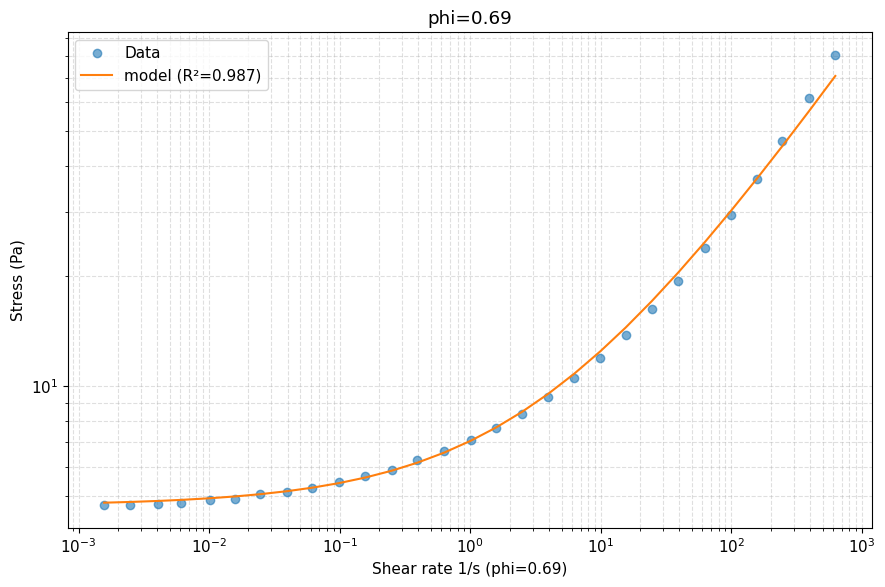

sample: 100%|██████████| 700/700 [00:12<00:00, 54.62it/s, 63 steps of size 5.88e-02. acc. prob=0.94]


Dataset 0: Bayesian inference complete for model


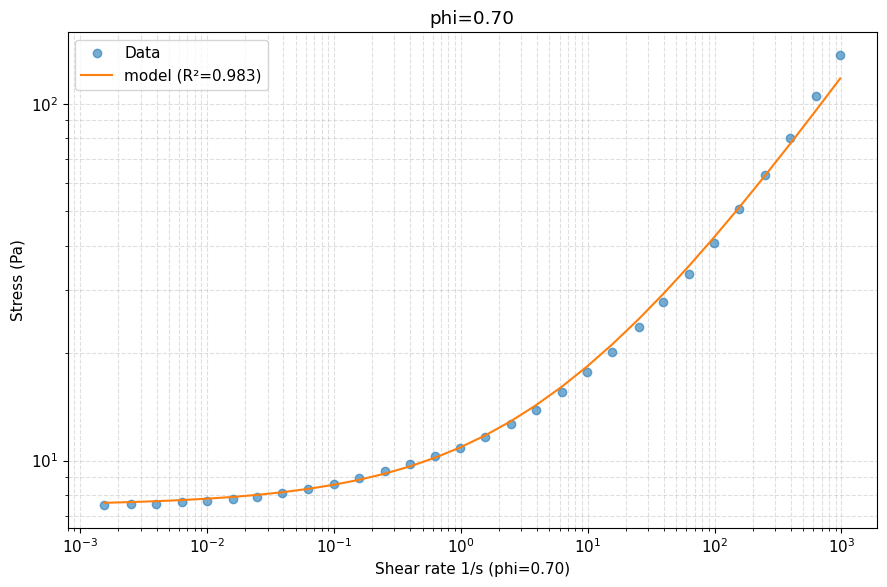

sample: 100%|██████████| 700/700 [00:12<00:00, 57.70it/s, 63 steps of size 8.04e-02. acc. prob=0.93]


Dataset 1: Bayesian inference complete for model


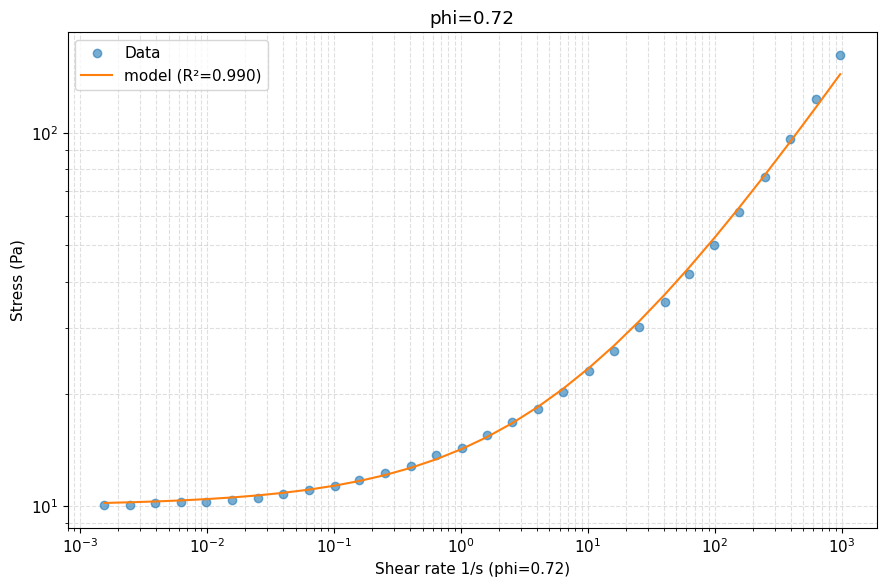

sample: 100%|██████████| 700/700 [00:14<00:00, 49.17it/s, 63 steps of size 4.70e-02. acc. prob=0.97] 


Dataset 2: Bayesian inference complete for model


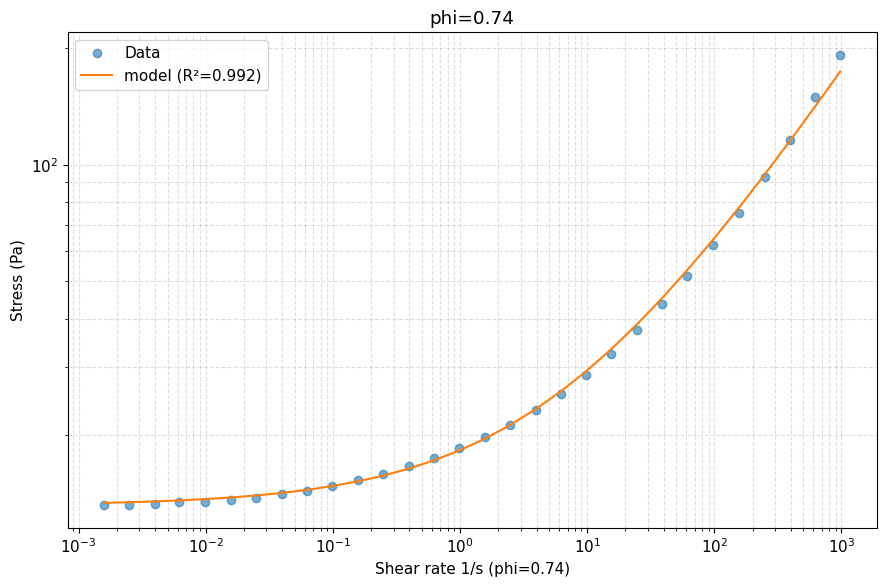

sample: 100%|██████████| 700/700 [00:12<00:00, 57.11it/s, 63 steps of size 7.68e-02. acc. prob=0.94]


Dataset 3: Bayesian inference complete for model


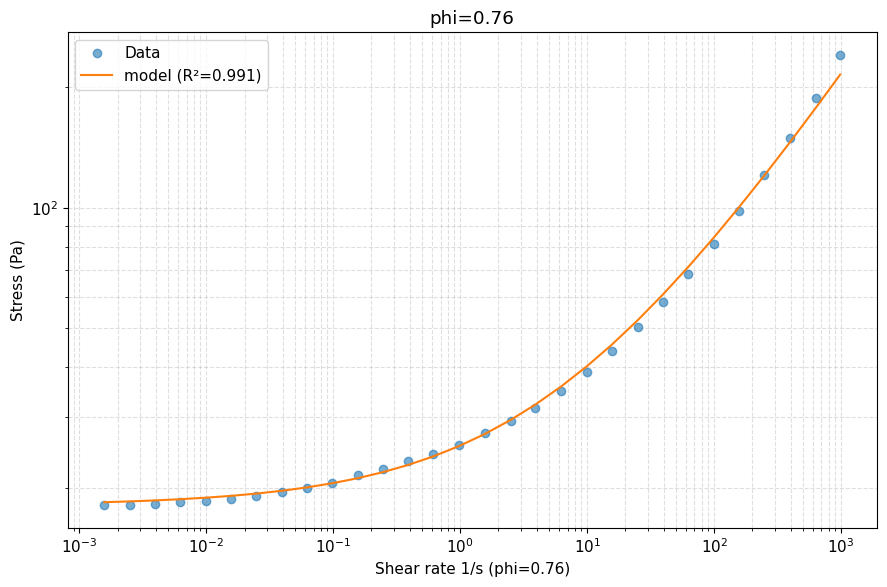

sample: 100%|██████████| 700/700 [00:13<00:00, 52.13it/s, 63 steps of size 6.79e-02. acc. prob=0.95] 


Dataset 4: Bayesian inference complete for model


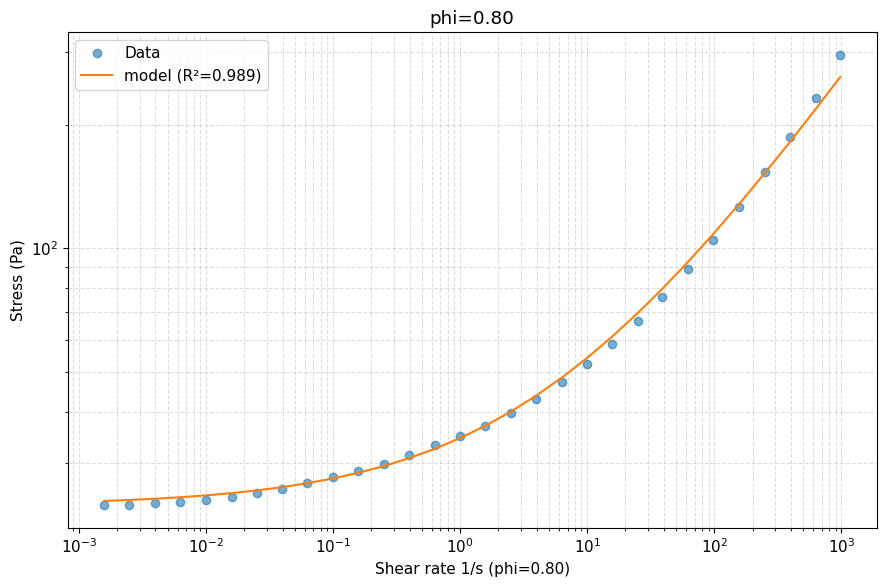

sample: 100%|██████████| 700/700 [00:13<00:00, 53.26it/s, 63 steps of size 6.74e-02. acc. prob=0.96] 

Dataset 5: Bayesian inference complete for model


In [8]:
# Bayesian inference on best model per dataset
def _plot_data_and_fits(ds, fits):
    """Plot data with model fits overlay."""
    fig, ax = plt.subplots(figsize=(9, 6))
    X_plot, y_true = ds['X'], ds['y']
    if np.iscomplexobj(y_true):
        x_axis = X_plot / (2 * np.pi) if ds['test_mode'] == 'oscillation' else X_plot
        ax.loglog(x_axis, np.real(y_true), 'o', label="Data real", alpha=0.6)
        ax.loglog(x_axis, np.imag(y_true), 's', label="Data imag", alpha=0.6)
        for rec in fits:
            pred = _coerce_pred(rec['pred'])
            ax.loglog(x_axis, np.real(pred), '-', label=f"{rec['name']} Re (R²={rec['r2']:.3f})")
            ax.loglog(x_axis, np.imag(pred), '--', label=f"{rec['name']} Im")
    else:
        ax.loglog(X_plot, y_true, 'o', label='Data', alpha=0.6)
        for rec in fits:
            ax.loglog(X_plot, rec['pred'], '-', label=f"{rec['name']} (R²={rec['r2']:.3f})")
    ax.set_xlabel(ds.get('x_label', 'X'))
    ax.set_ylabel(ds.get('y_label', 'Response'))
    ax.set_title(ds.get('label', f"test_mode={ds['test_mode']}"))
    ax.grid(True, which='both', ls='--', alpha=0.4)
    ax.legend()
    plt.tight_layout()
    display(fig)
    plt.close(fig)

bayes_results = {}  # {dataset_idx: (bayes_result, param_names)}

for ds_idx, ds in enumerate(datasets):
    fits = all_fits.get(ds_idx, [])
    if not fits:
        continue

    best = fits[0]
    _plot_data_and_fits(ds, fits)

    try:
        bayes_result = best['model'].fit_bayesian(
            ds['X'], ds['y'], **NUTS_CONFIG, test_mode=ds['test_mode'],
        )
        param_names = list(best['model'].parameters.keys())
        bayes_results[ds_idx] = (bayes_result, param_names)
        print(f"Dataset {ds_idx}: Bayesian inference complete for {best['name']}")
    except Exception as exc:
        print(f"Dataset {ds_idx}: Bayesian step failed for {best['name']}: {exc}")



--- Diagnostics for dataset 0 ---


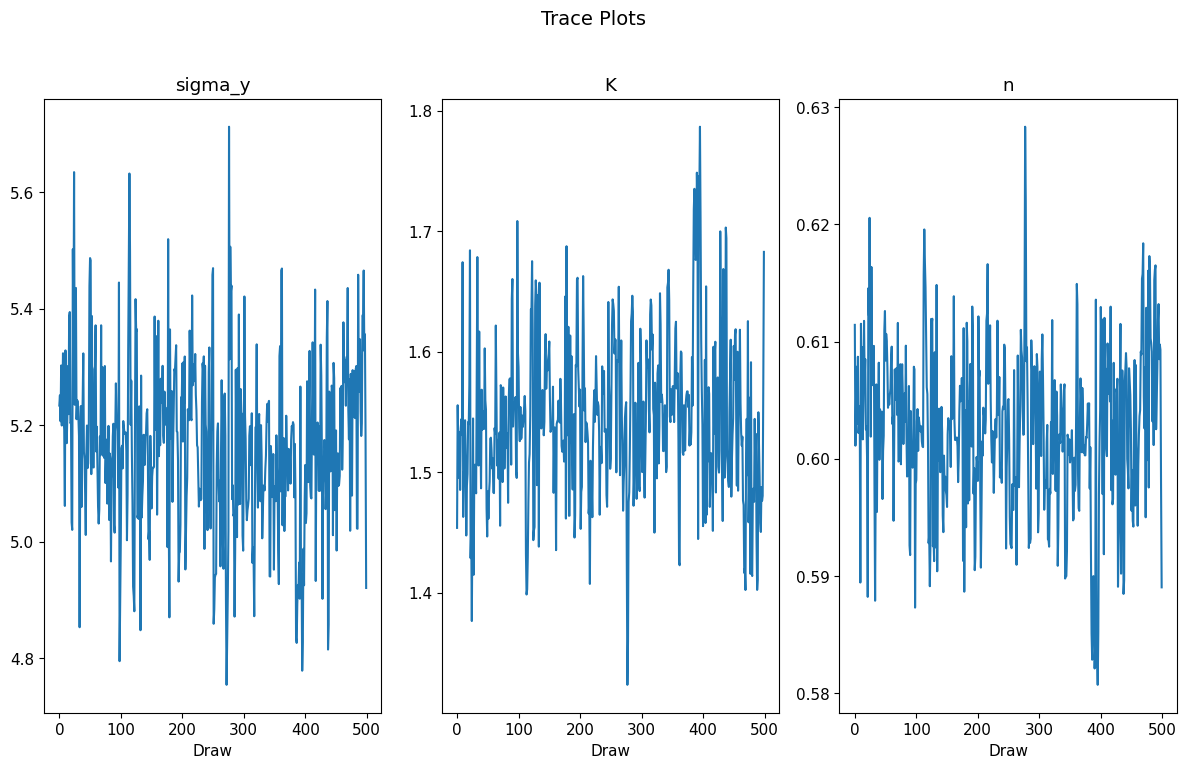

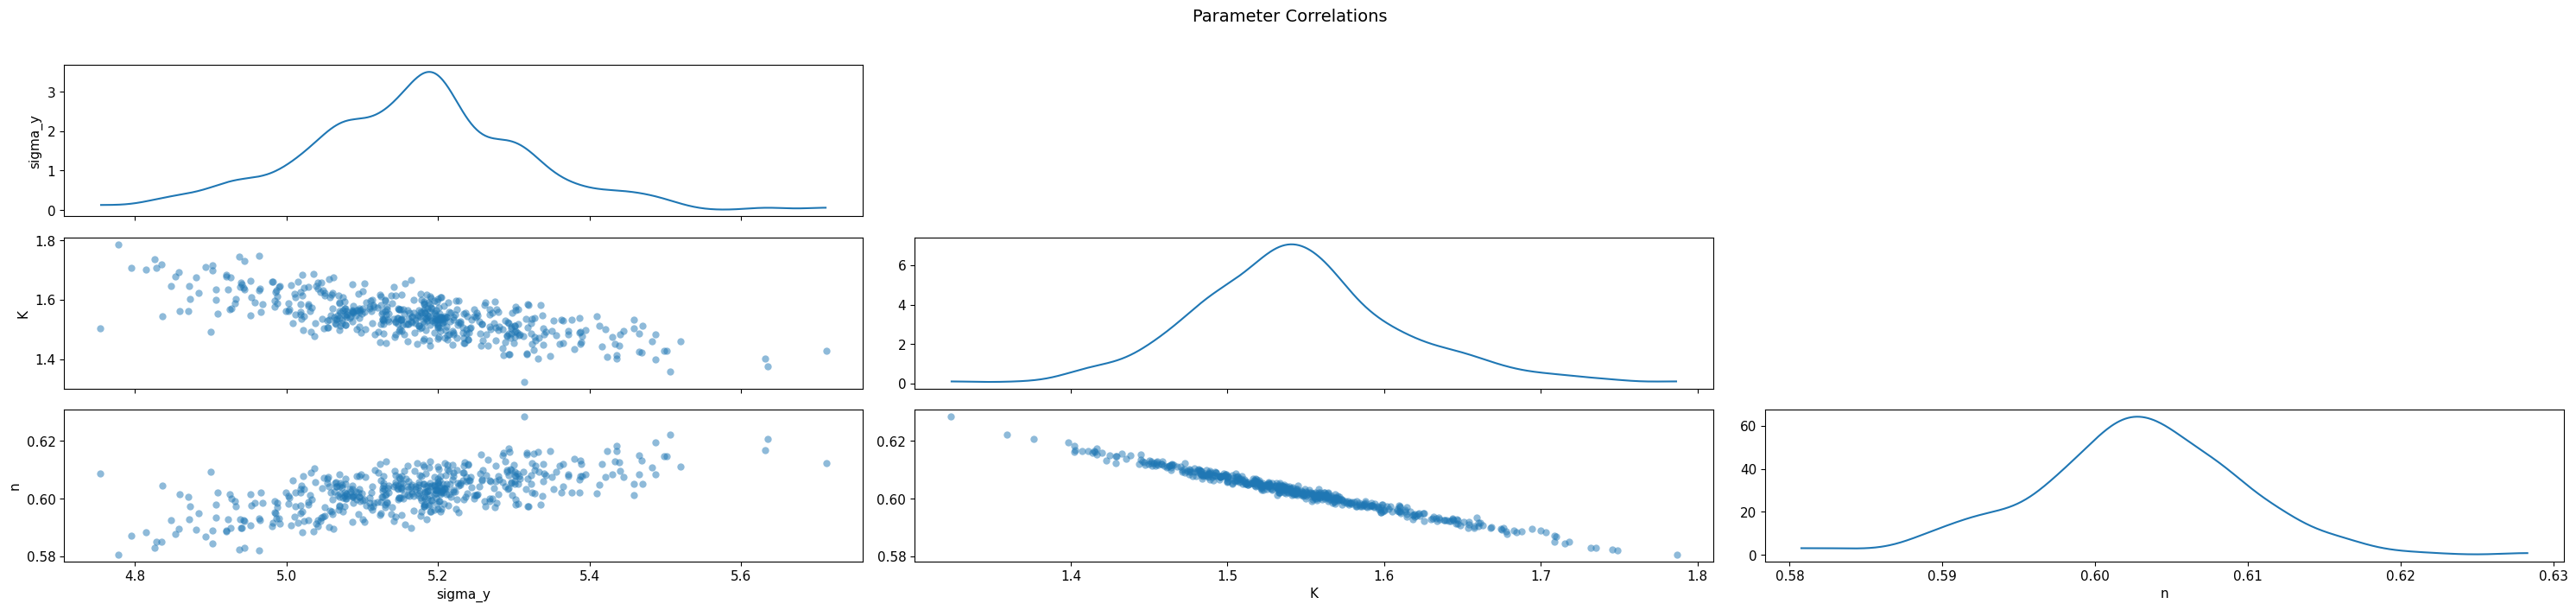

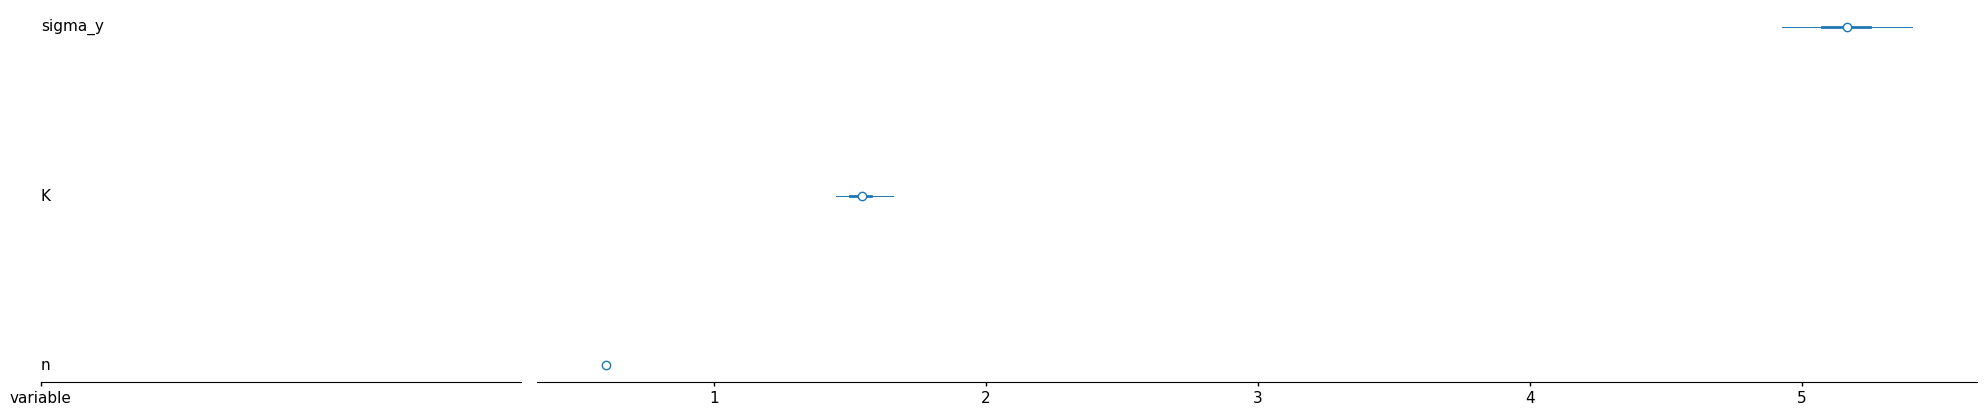

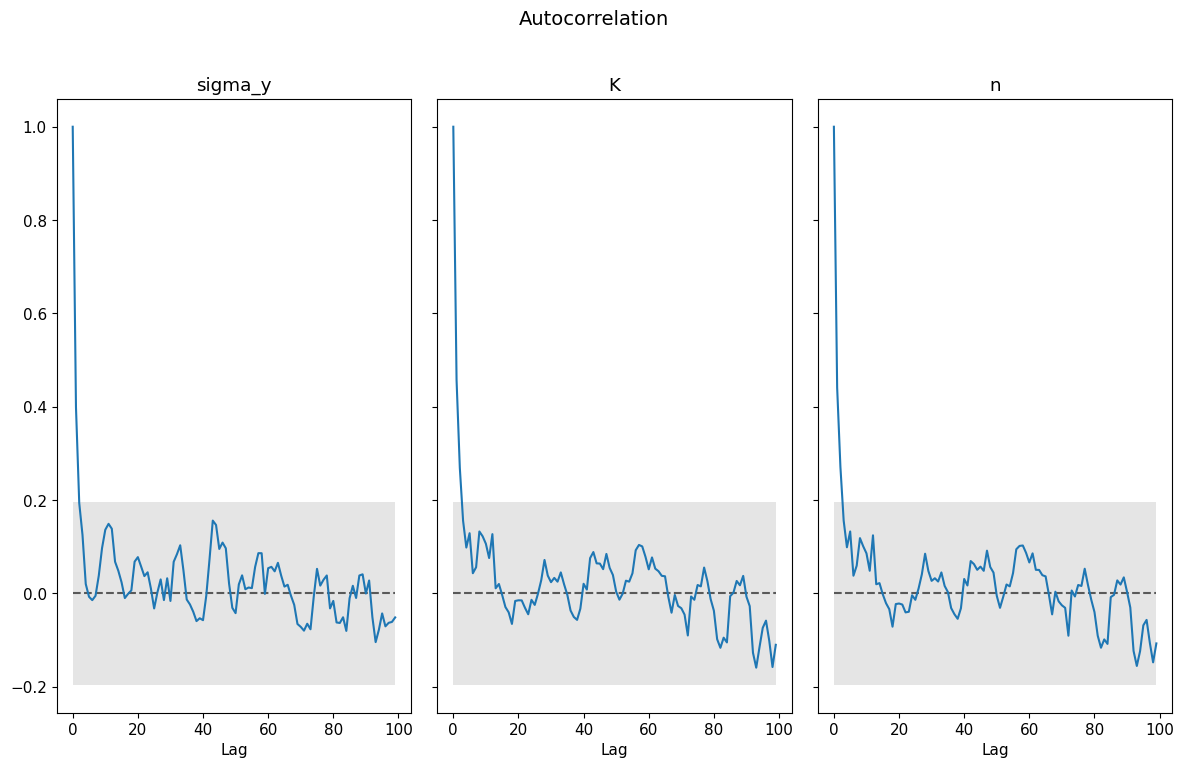


--- Diagnostics for dataset 1 ---


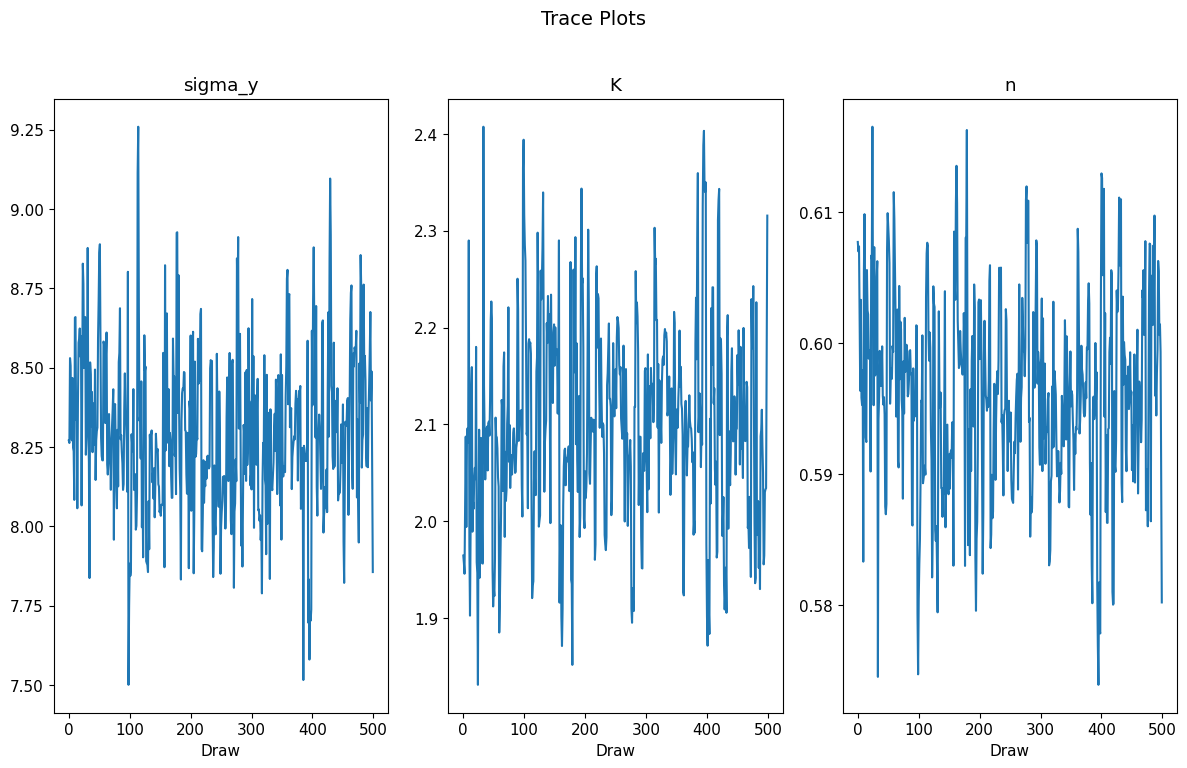

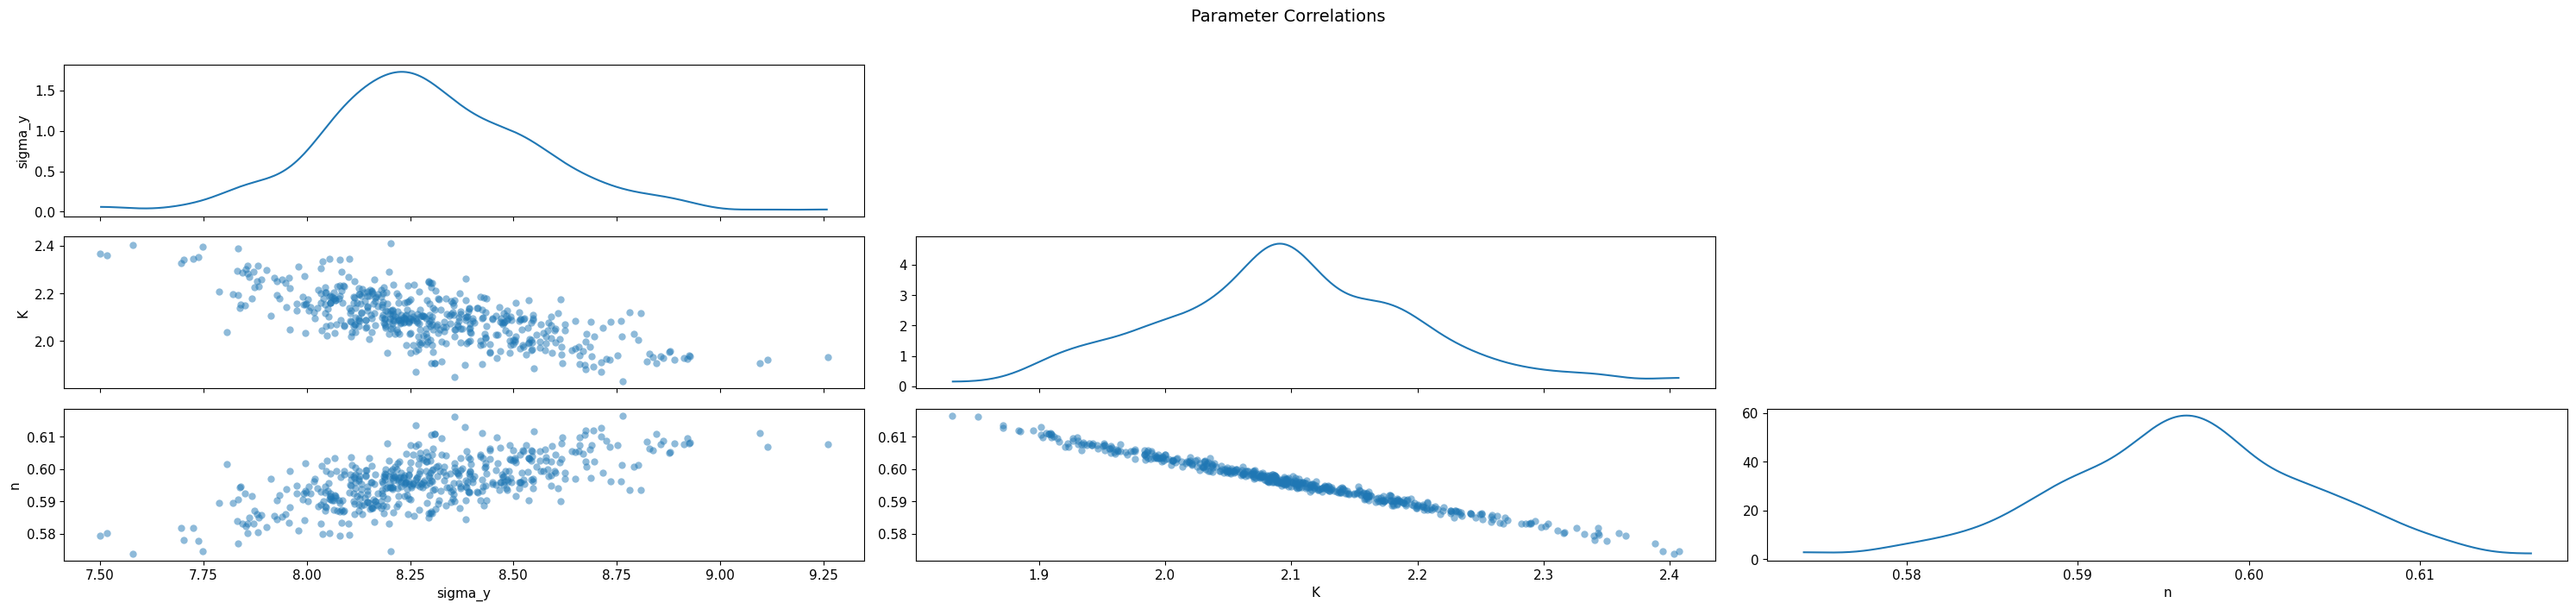

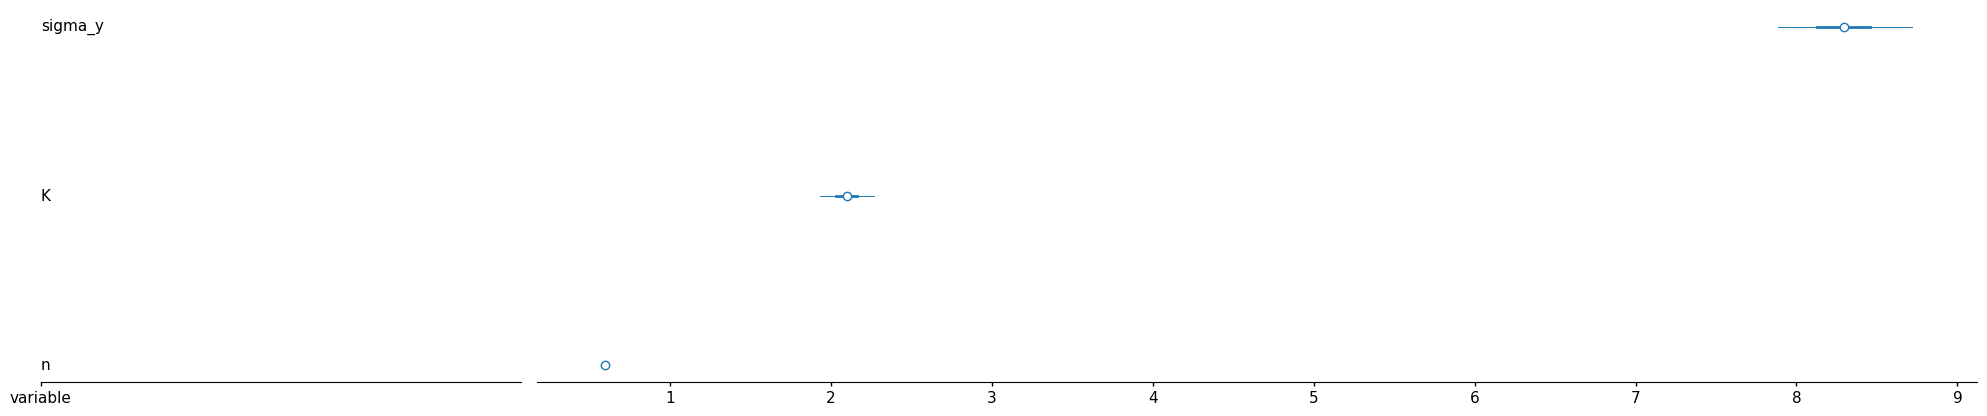

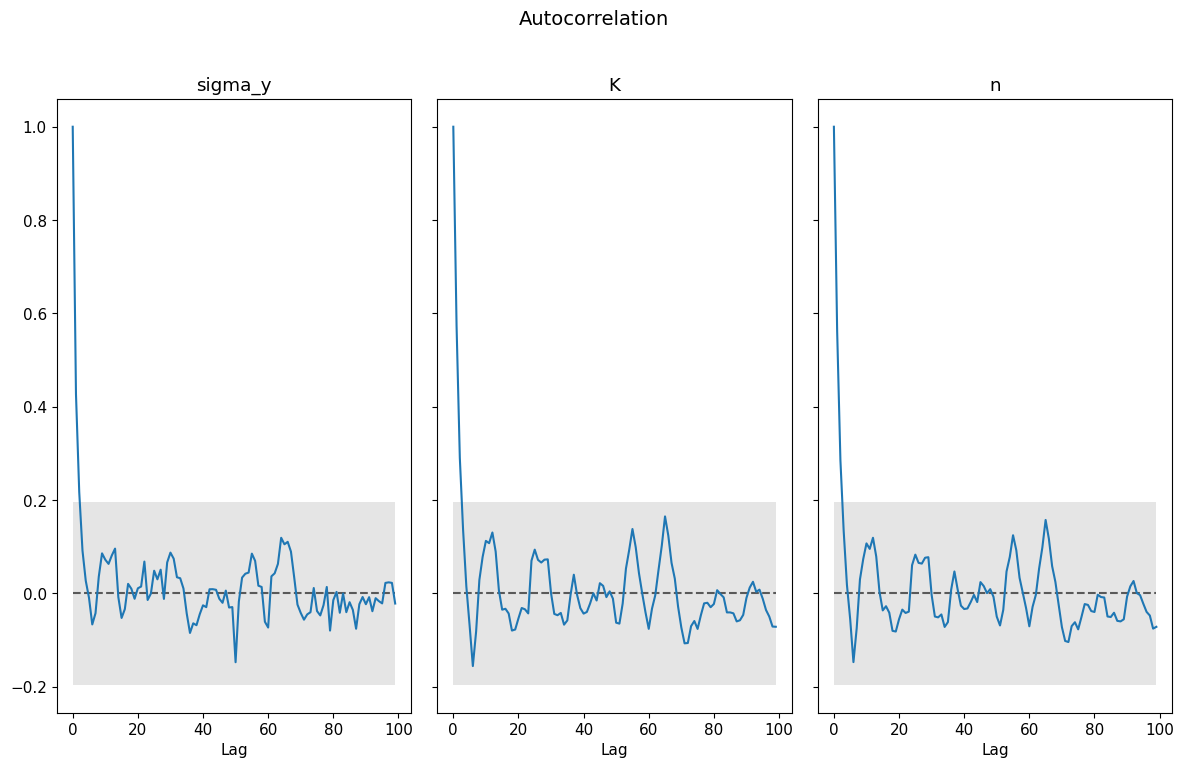


--- Diagnostics for dataset 2 ---


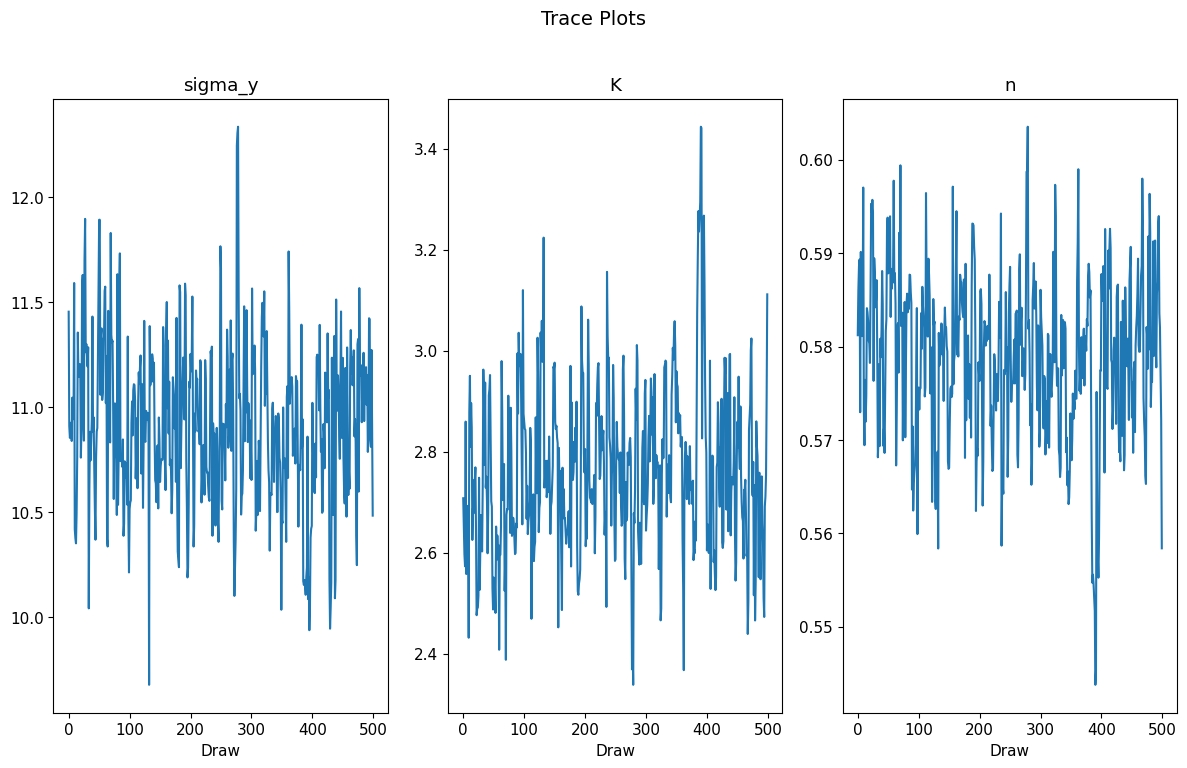

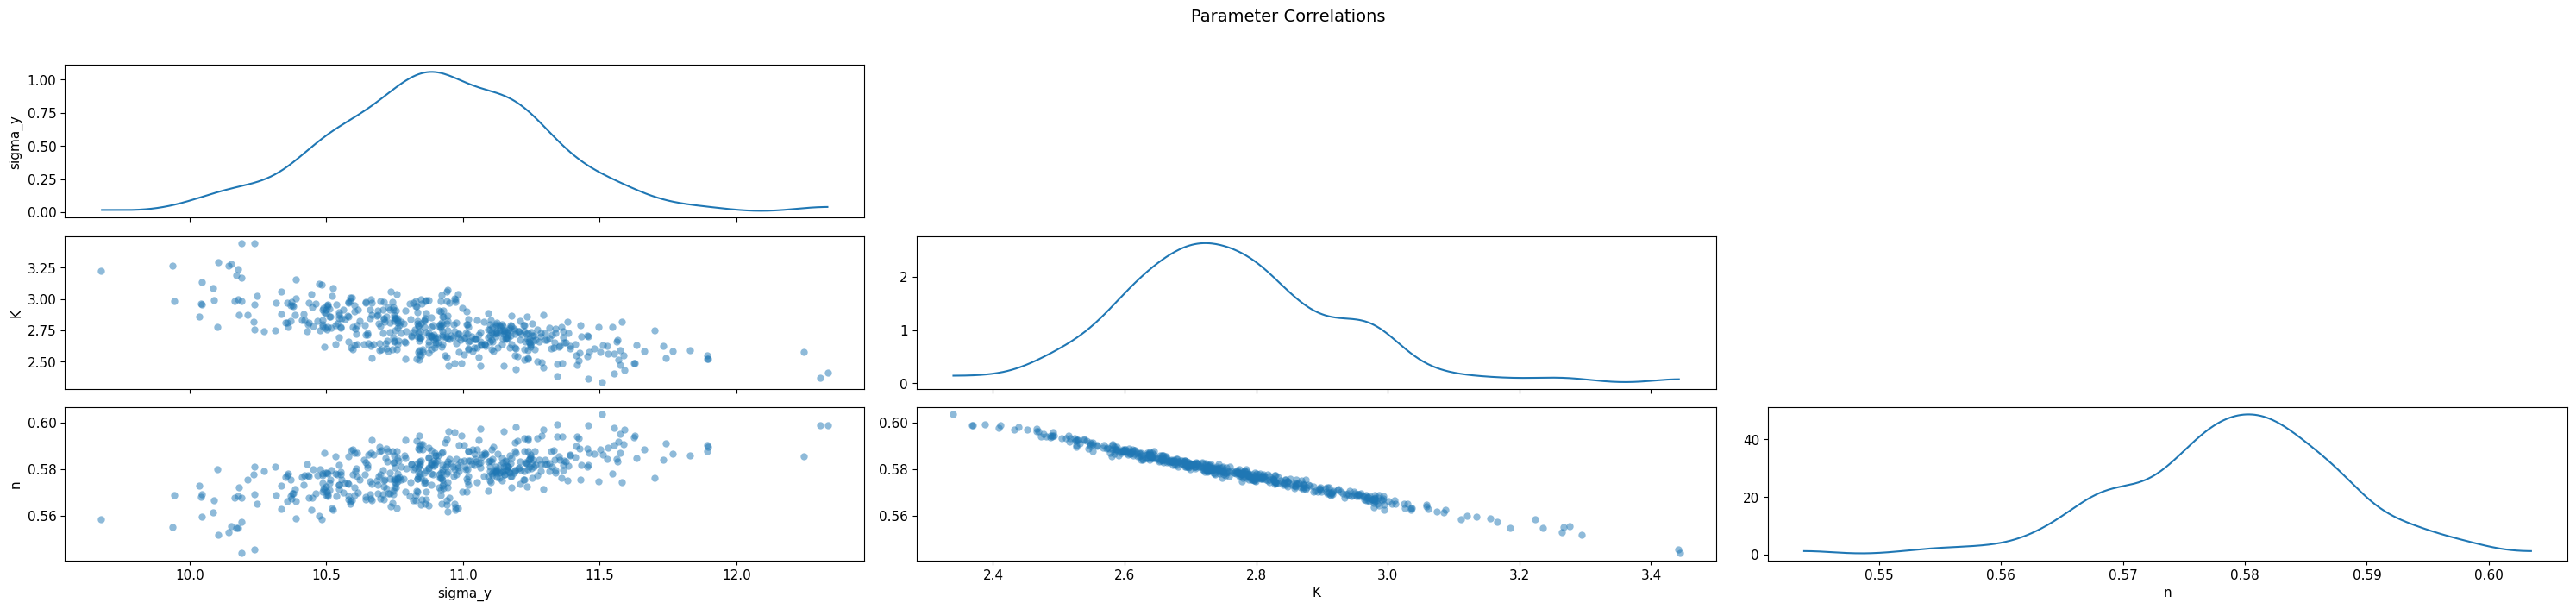

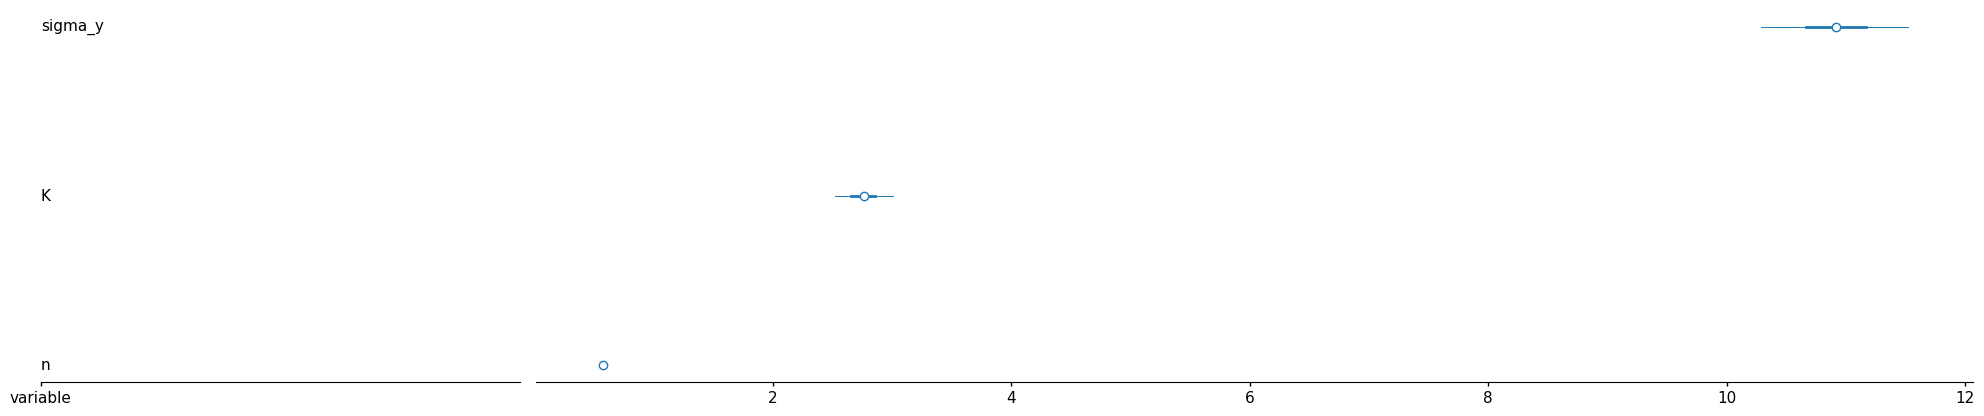

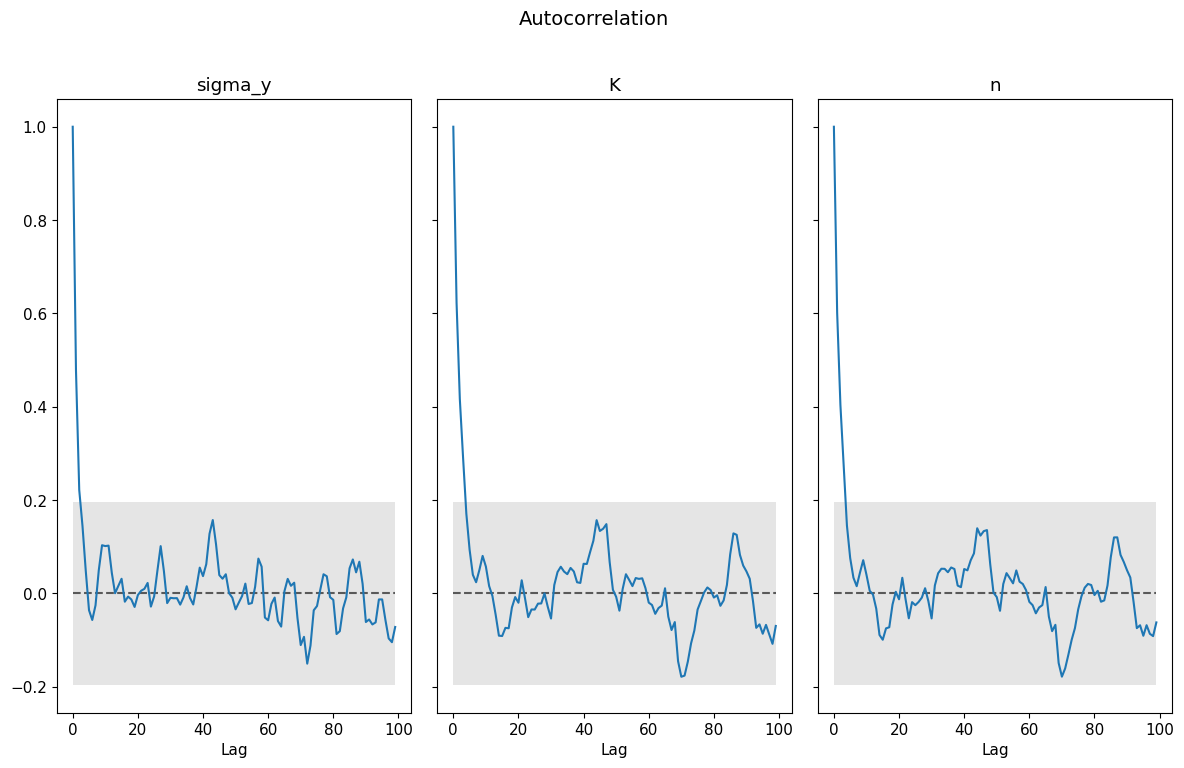


--- Diagnostics for dataset 3 ---


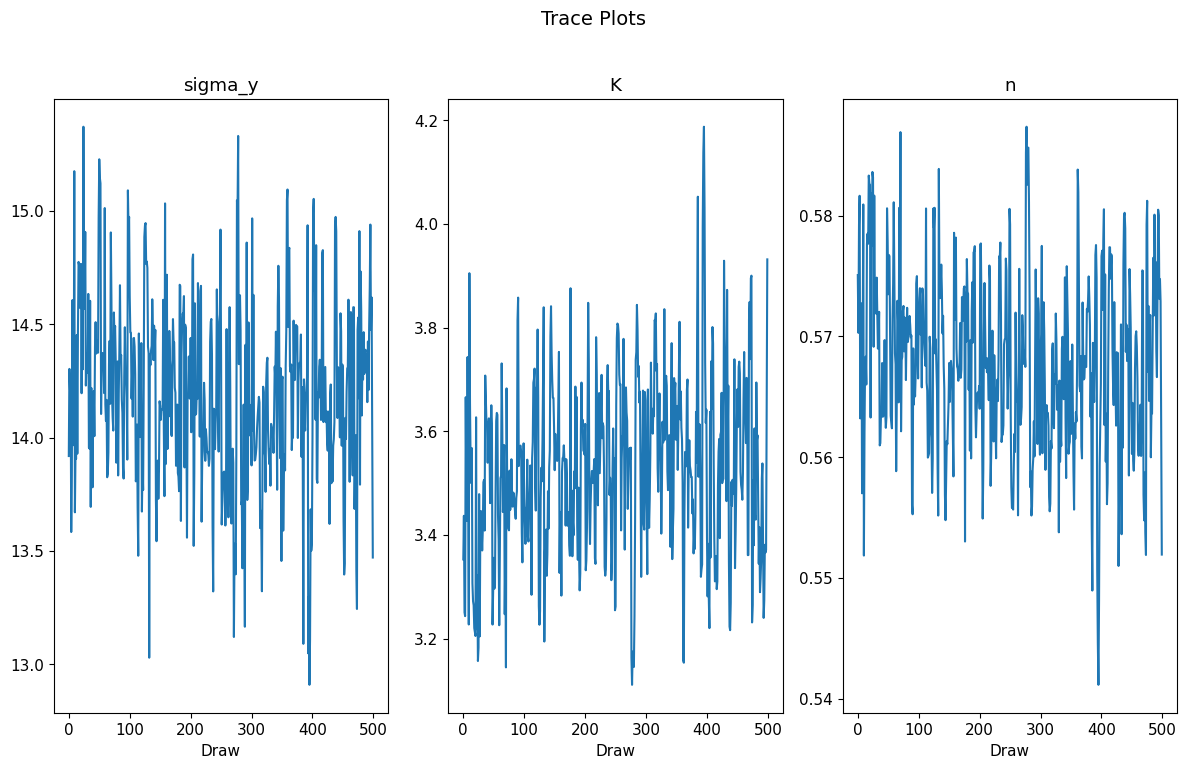

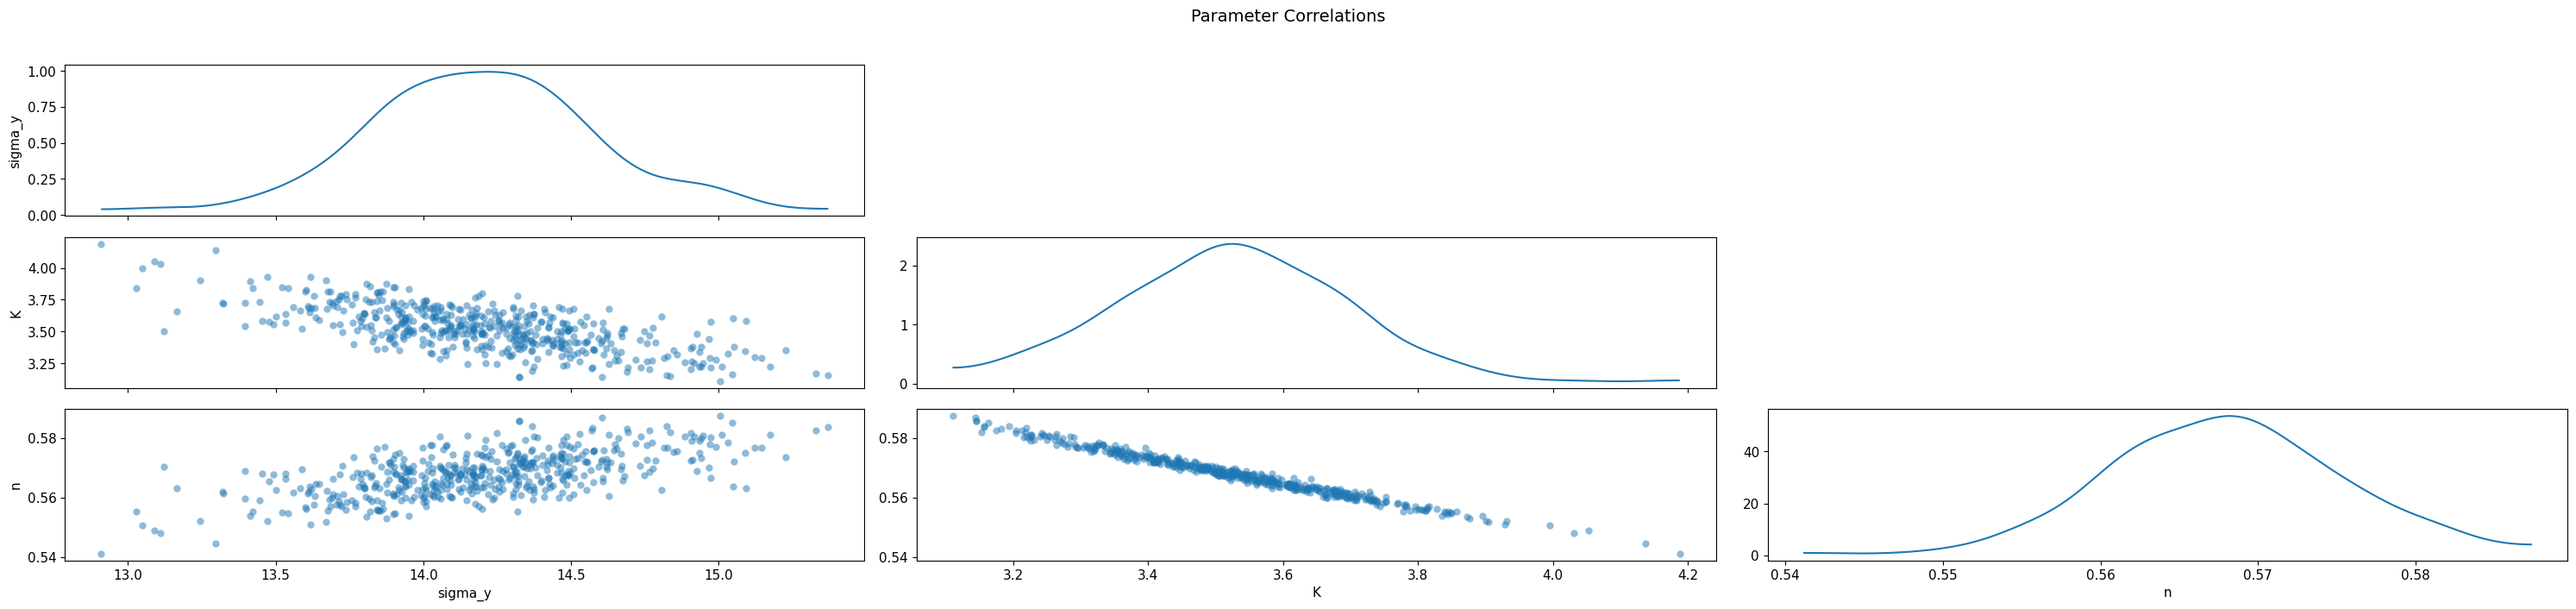

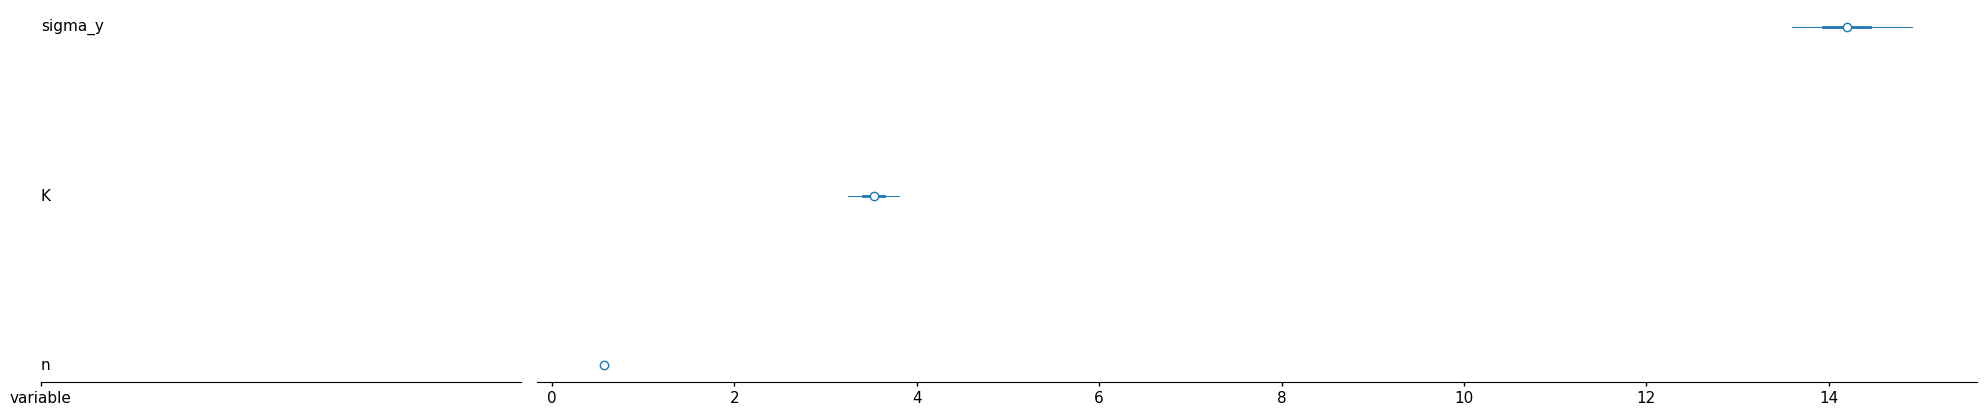

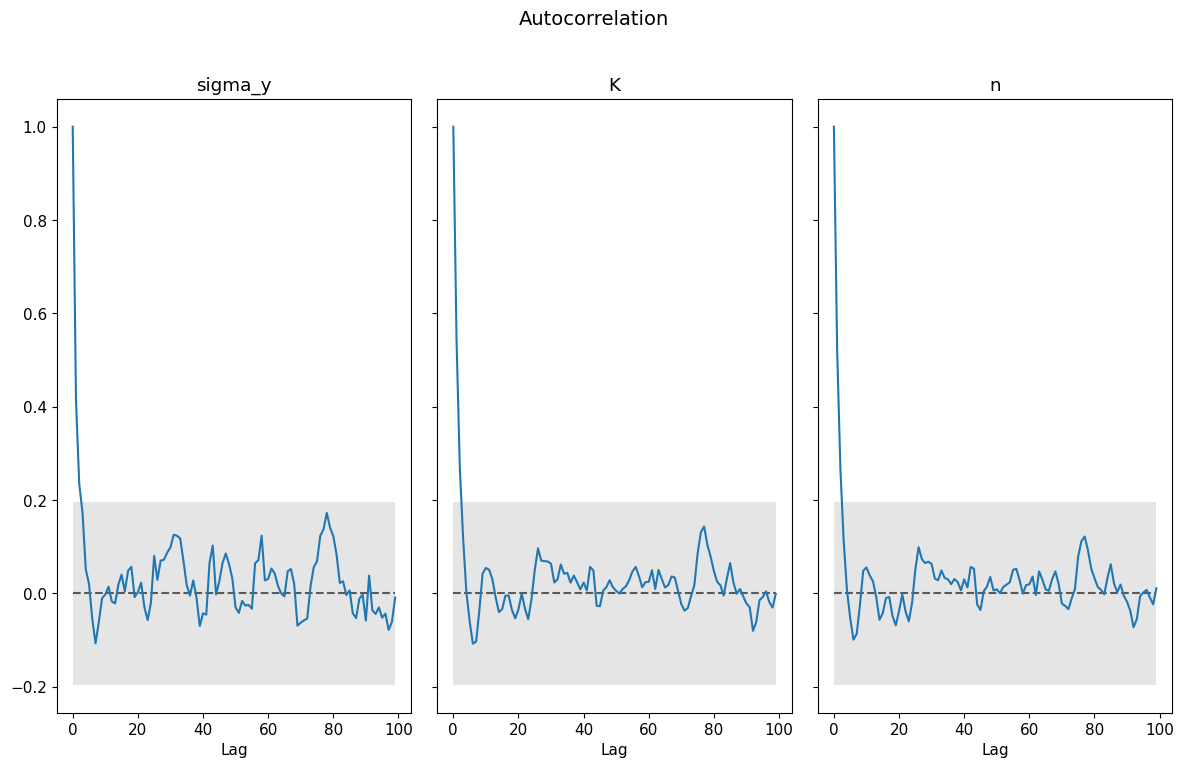


--- Diagnostics for dataset 4 ---


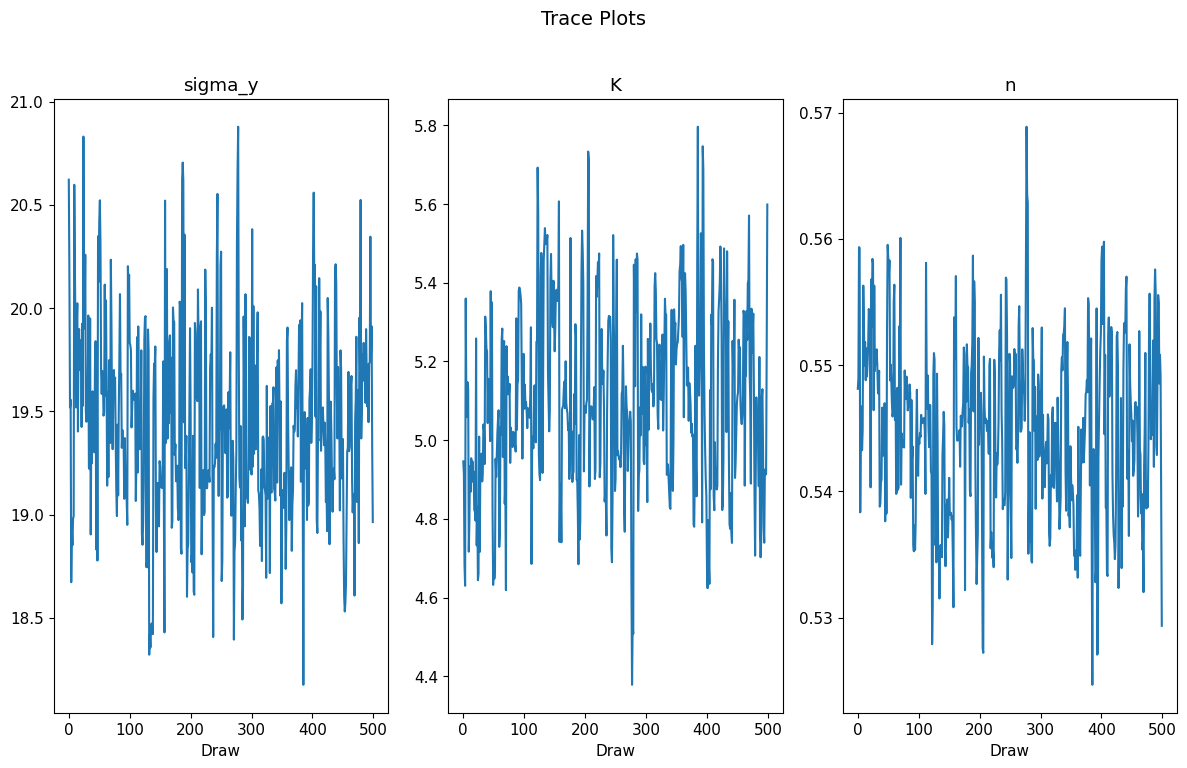

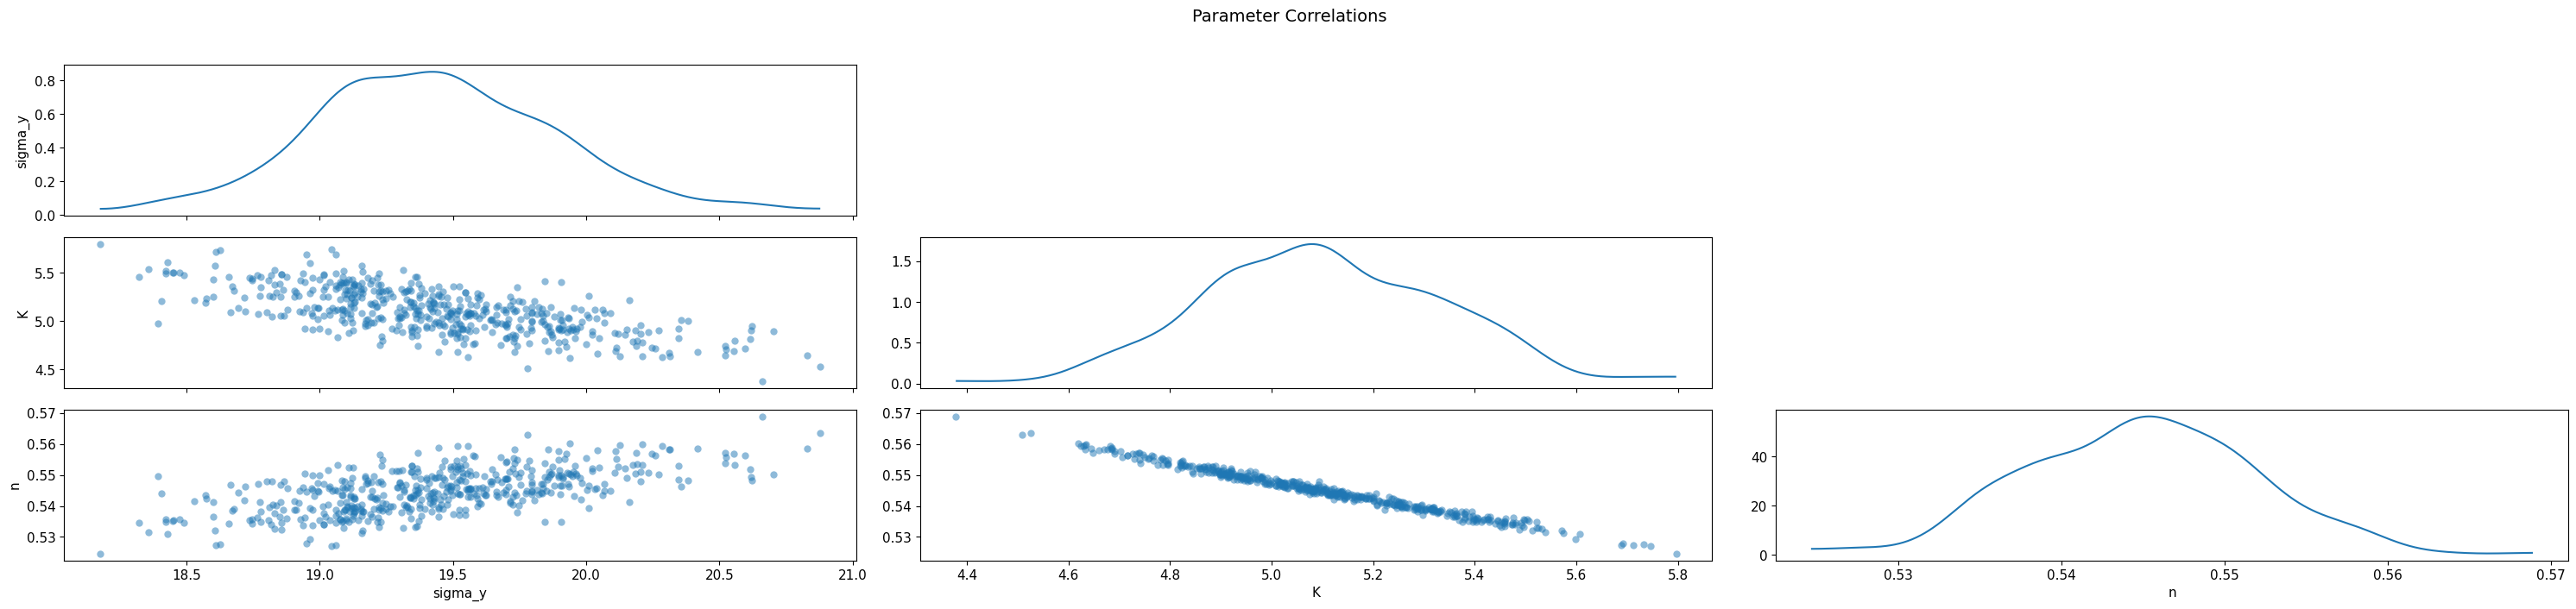

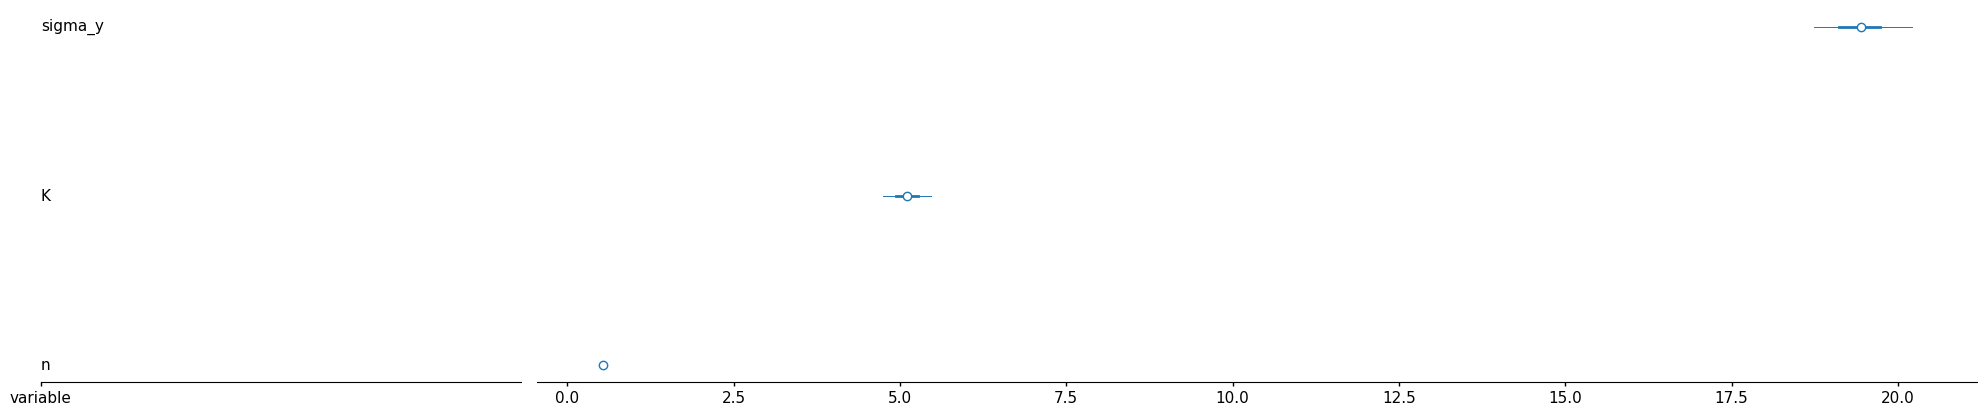

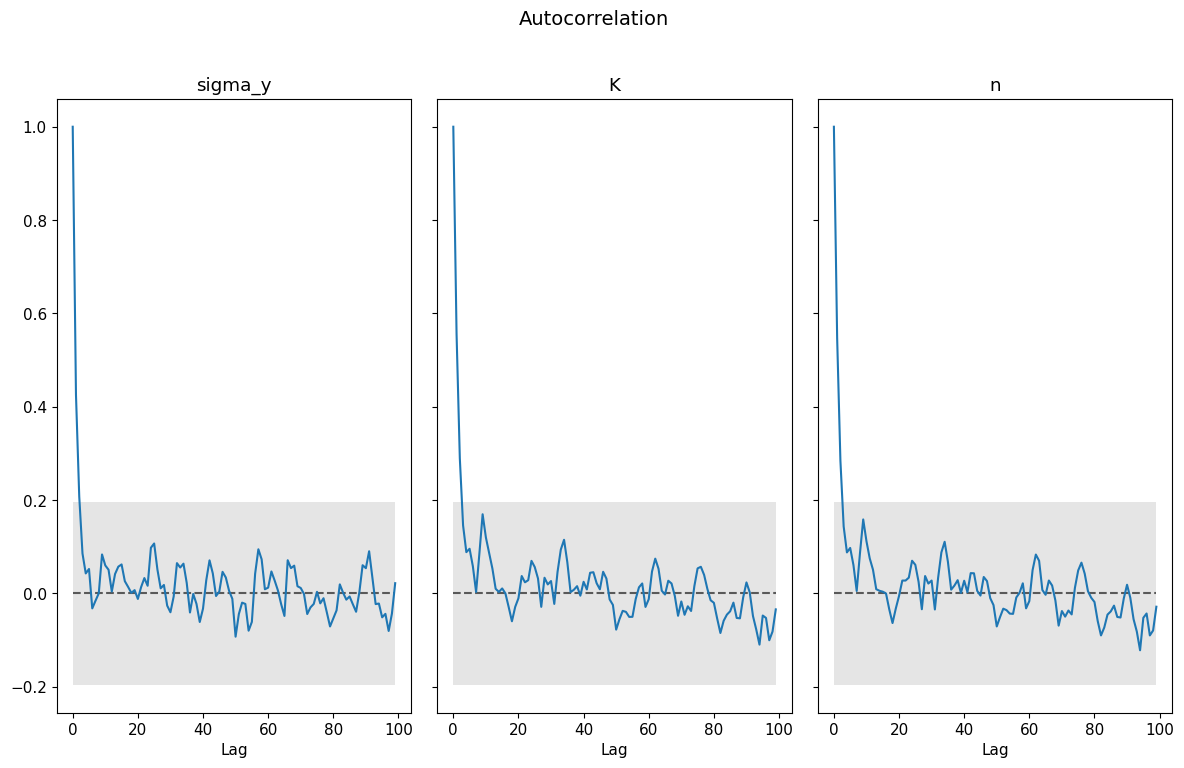


--- Diagnostics for dataset 5 ---


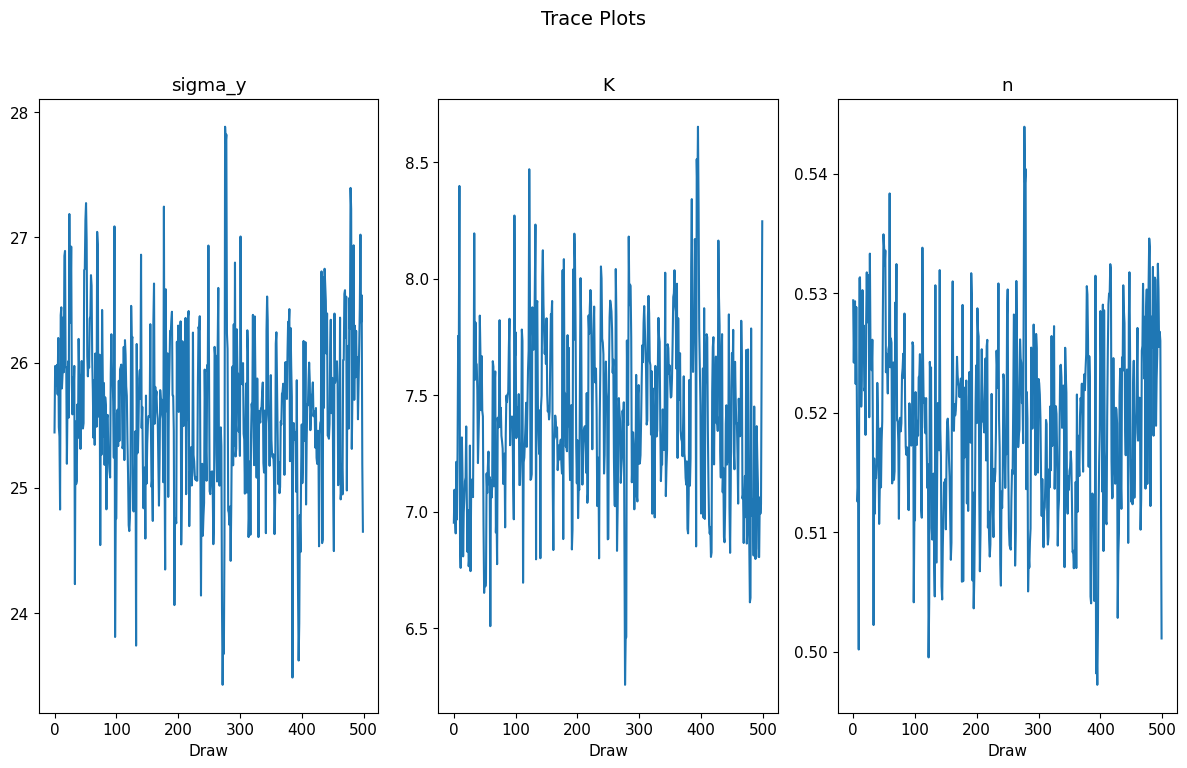

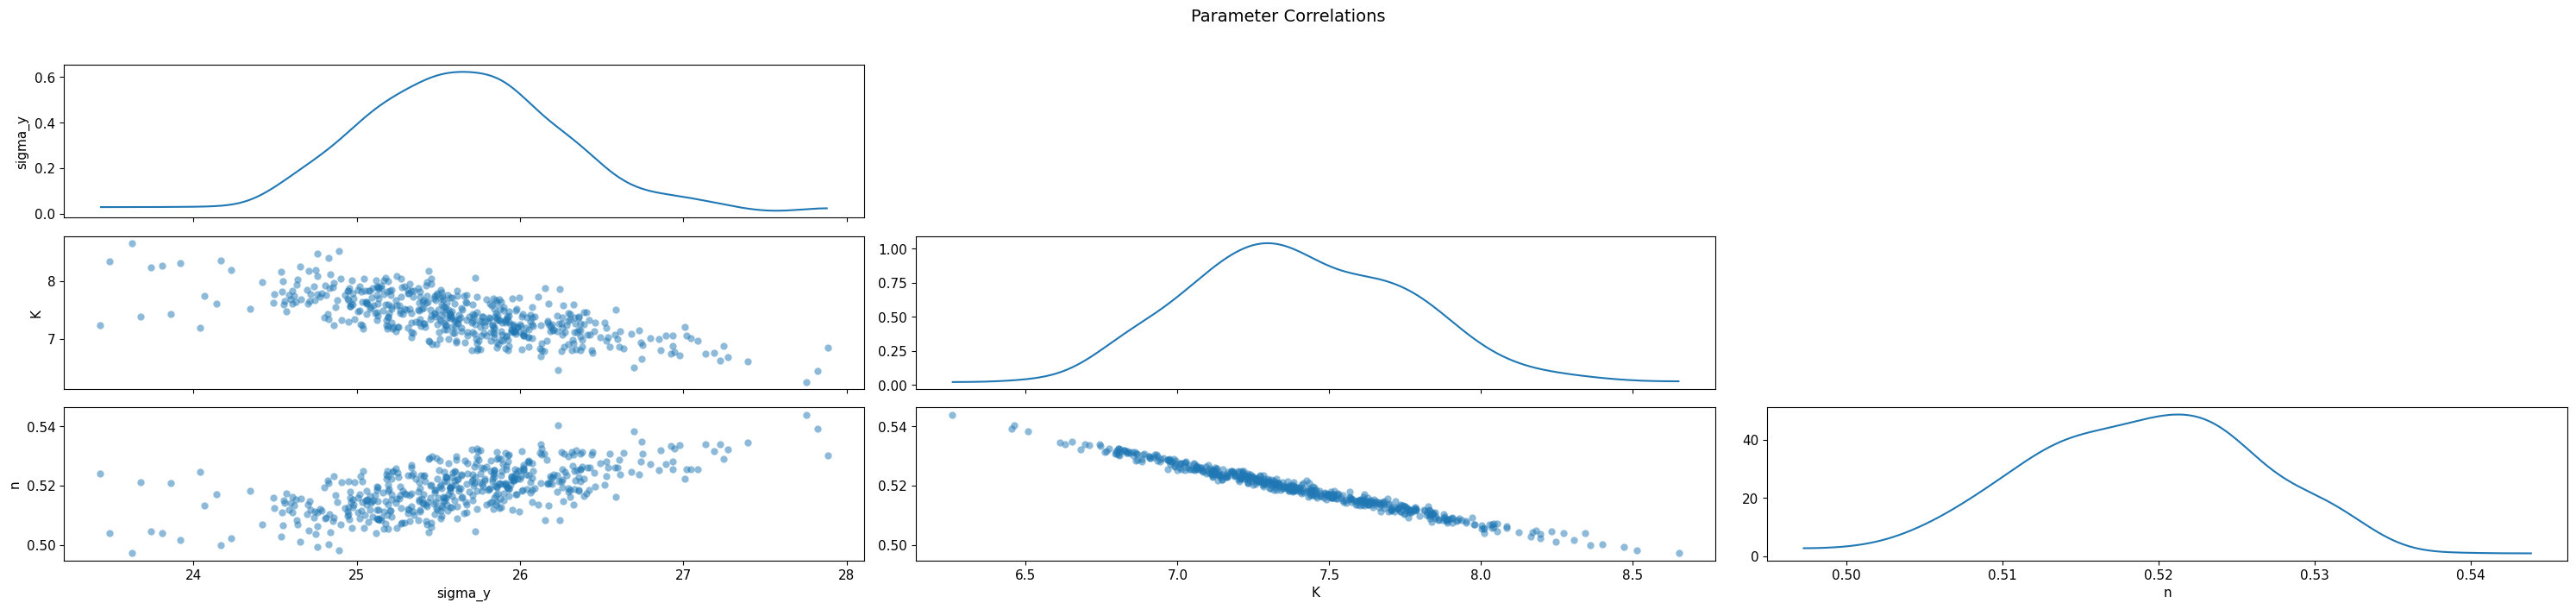

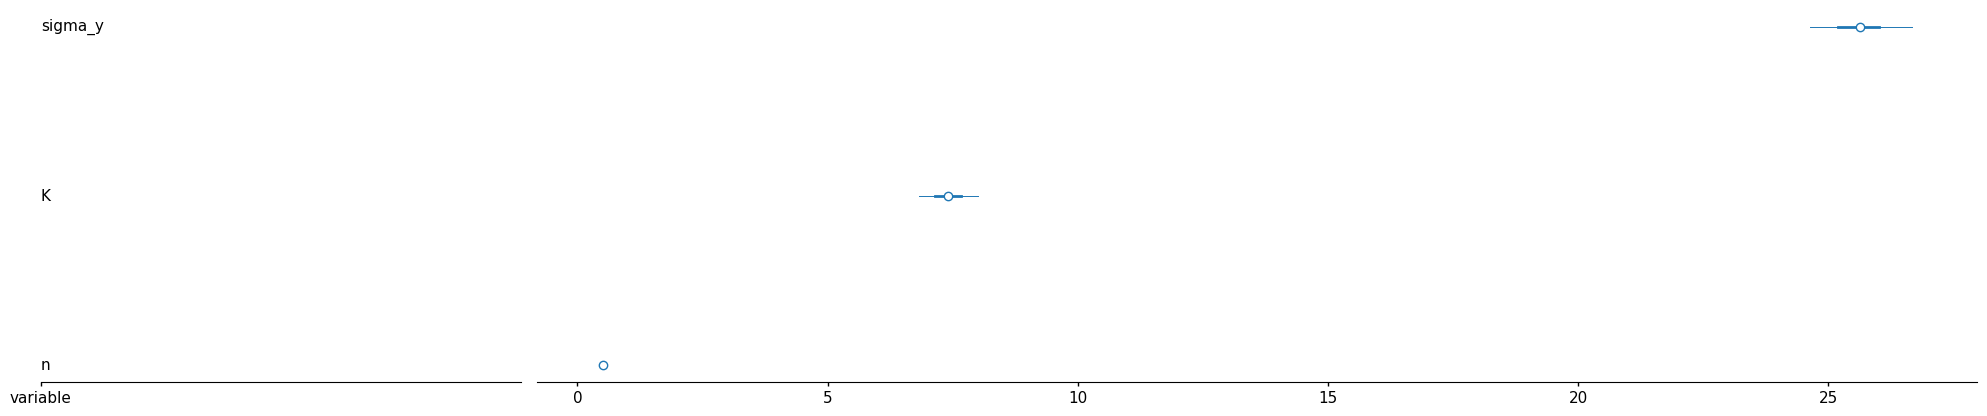

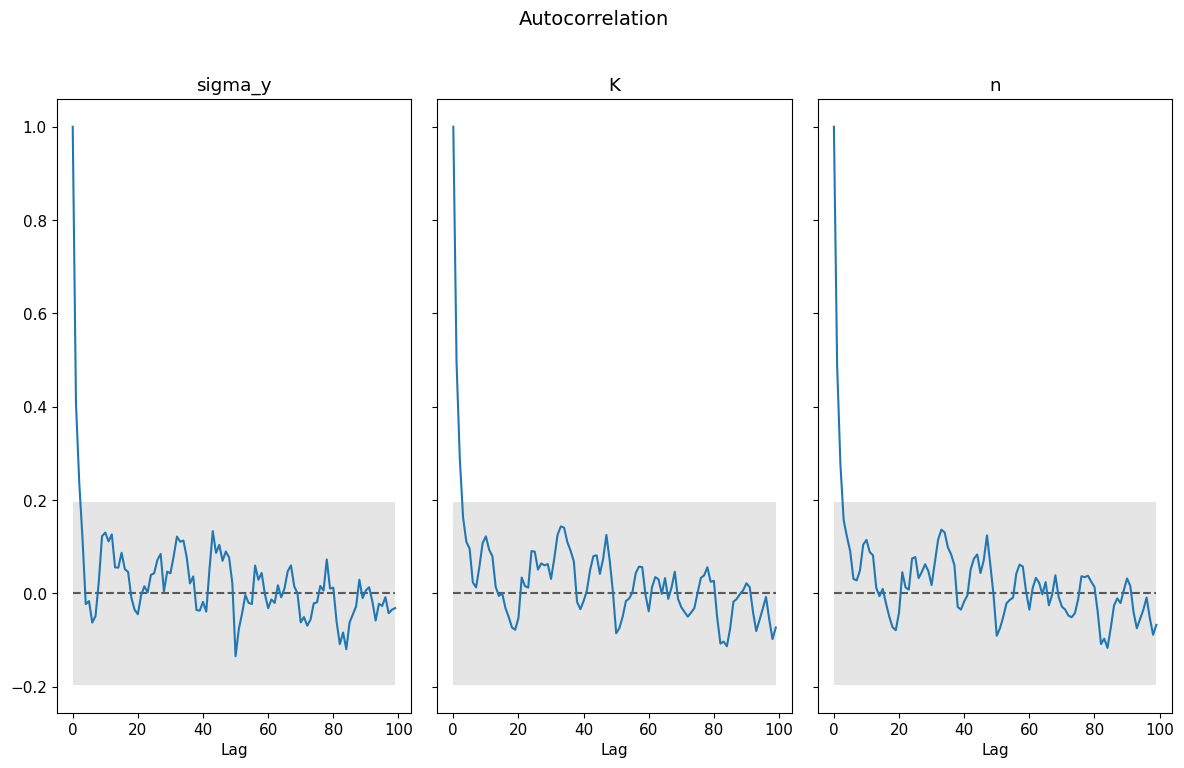

In [9]:
# ArviZ diagnostics for Bayesian results
for ds_idx, (bayes_result, param_names) in bayes_results.items():
    print(f"\n--- Diagnostics for dataset {ds_idx} ---")
    display_arviz_diagnostics(bayes_result, param_names, fast_mode=True)
